## Figure. Reproducing O'brien CB vs Unfiltered

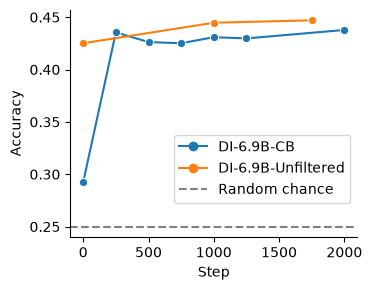

In [ ]:
import json
from pathlib import Path

import pandas as pd
import seaborn as sns

configs = [
    {
        "path": "../artifacts/evals/unfiltered-wmdp-bio-lora",
        "name": "DI-6.9B-Unfiltered",
    },
    {
        "path": "../artifacts/evals/unfiltered-cb-wmdp-bio-lora",
        "name": "DI-6.9B-CB",
    },
]

rows = []

for config in configs:
    for checkpoint_dir in Path(config["path"]).glob("checkpoint-*"):
        result_files = list(checkpoint_dir.rglob("results*.json"))

        if not result_files:
            continue

        # Use the newest result if a checkpoint was evaluated more than once.
        result_file = max(result_files, key=lambda path: path.stat().st_mtime)
        results = json.loads(result_file.read_text())

        rows.append(
            {
                "Model": config["name"],
                "Step": int(checkpoint_dir.name.removeprefix("checkpoint-")),
                "Accuracy": results["results"]["wmdp_bio_robust"]["acc,none"],
            }
        )

df = pd.DataFrame(rows).sort_values(["Model", "Step"])
# g = sns.relplot(
#     data=df,
#     x="Step",
#     y="Accuracy",
#     hue="Model",
#     kind="line",
#     marker="o",
#     height=3,
#     aspect=1.3,
# )
# g.ax.axhline(0.25, color="gray", linestyle="--", label="Random chance")

g = sns.relplot(
    data=df,
    x="Step",
    y="Accuracy",
    hue="Model",
    kind="line",
    marker="o",
    height=3,
    aspect=1.3,
    facet_kws={"legend_out": False},
)

g.ax.axhline(
    0.25,
    color="gray",
    linestyle="--",
    label="Random chance",
)

g.ax.legend(
    title=None,
    loc="lower right",
    bbox_to_anchor=(1, 0.12),
)